In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

c:\Users\karim\Documents\9raya\Junior_BA_IT\S2\Data Mining\final project\sign language\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\karim\.cache\kagglehub\datasets\datamunge\sign-language-mnist\versions\1


In [2]:
import pandas as pd

df = pd.read_csv("1/sign_mnist_train.csv")  # or your file name

In [3]:
df_train = pd.read_csv("1/sign_mnist_train.csv")
df_test = pd.read_csv("1/sign_mnist_test.csv")

df = pd.concat([df_train, df_test], ignore_index=True)

In [4]:
df.shape
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34627 entries, 0 to 34626
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 207.4 MB


In [5]:
X = df.drop("label", axis=1)
y = df["label"]
y

0         3
1         6
2         2
3         2
4        13
         ..
34622     1
34623    12
34624     2
34625     4
34626     2
Name: label, Length: 34627, dtype: int64

In [6]:
sorted(y.unique())
len(y.unique())

24

In [7]:
y.value_counts().sort_index()

label
0     1457
1     1442
2     1454
3     1441
4     1455
5     1451
6     1438
7     1449
8     1450
10    1445
11    1450
12    1449
13    1442
14    1442
15    1435
16    1443
17    1438
18    1445
19    1434
20    1427
21    1428
22    1431
23    1431
24    1450
Name: count, dtype: int64

In [8]:
# Missing values: (We expect 0 for all columns)
df.isnull().sum().sum()

np.int64(0)

In [9]:
# Pixel value inspection (We expect values between 0 and 255)
X.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,...,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.000000,34627.00000
mean,145.857077,148.903226,151.677824,153.984983,156.616600,158.904121,160.847171,162.610911,164.293384,165.901868,...,140.574985,147.090479,152.791261,158.403211,161.332140,162.097063,161.923528,161.077136,160.211309,158.77919
std,41.839313,40.355637,39.355866,38.762706,37.252215,36.130753,35.274594,34.137995,32.882325,31.514255,...,63.914830,65.438124,64.713282,64.112086,64.055046,63.886450,64.166570,63.892399,64.395504,65.25230
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,122.000000,126.000000,130.000000,133.000000,137.000000,140.000000,143.000000,145.000000,146.000000,148.000000,...,91.500000,96.000000,102.000000,110.000000,118.000000,122.000000,124.000000,124.000000,124.000000,121.00000
50%,151.000000,154.000000,156.000000,158.000000,160.000000,163.000000,164.000000,166.000000,167.000000,168.000000,...,142.000000,161.000000,172.000000,179.000000,183.000000,183.000000,183.000000,182.000000,182.000000,181.00000
75%,175.000000,177.000000,179.000000,180.000000,181.000000,182.000000,184.000000,185.000000,185.000000,186.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,205.000000,204.00000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000


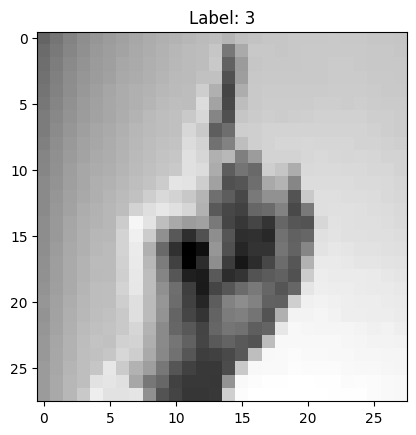

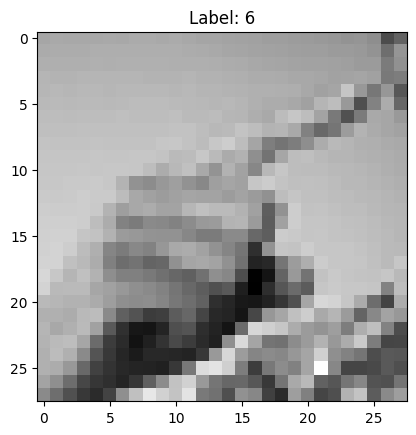

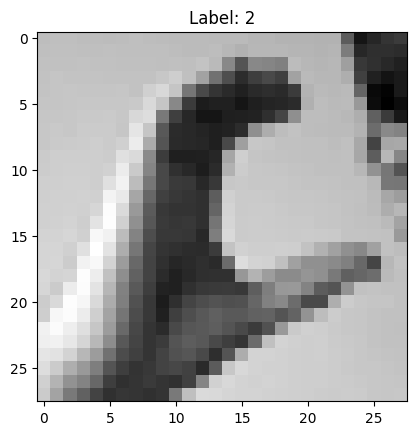

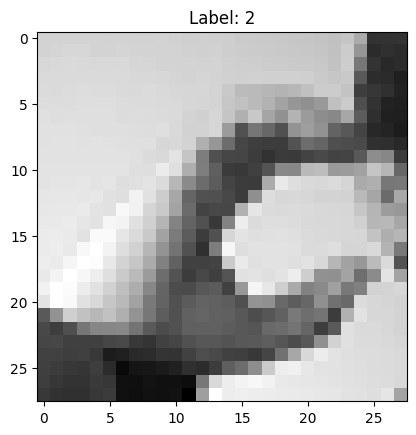

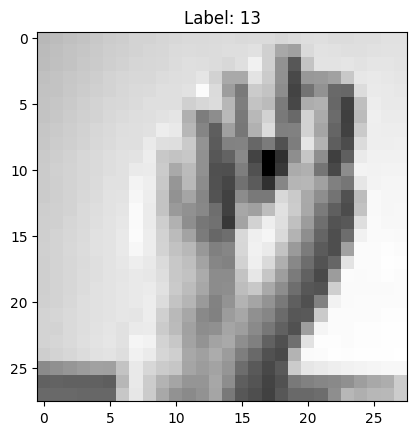

In [10]:
# Visualize images
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X.iloc[i].to_numpy().reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y.iloc[i]}")
    plt.show()

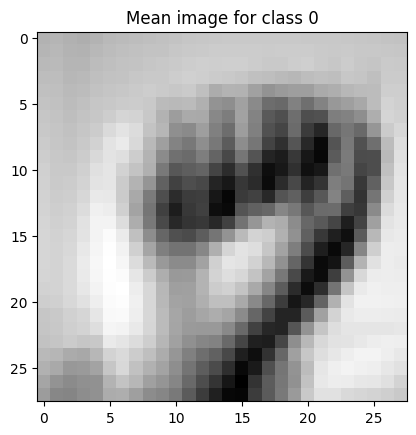

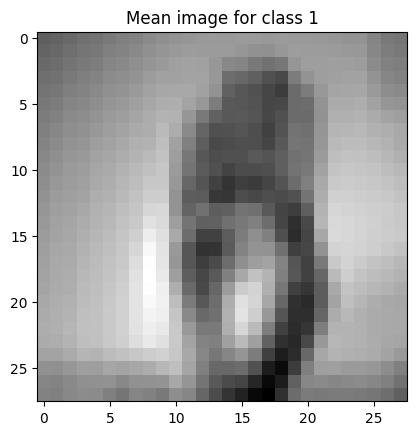

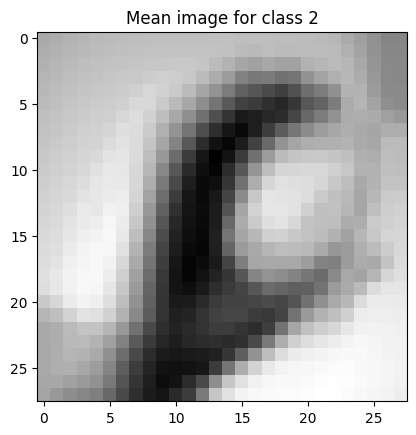

In [11]:
# Mean image per class
import numpy as np

for label in sorted(y.unique())[:3]:  # try few first
    mean_img = X[y == label].mean().values.reshape(28,28)
    plt.imshow(mean_img, cmap='gray')
    plt.title(f"Mean image for class {label}")
    plt.show()

In [12]:
X_train = df_train.drop("label", axis=1)
y_train = df_train["label"]
X_test = df_test.drop("label", axis=1)
y_test = df_test["label"]

In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Reshaping  

Right now:  

(784,) → flat vector  

But CNN needs:  

(28, 28, 1)  

CNN needs spatial structure:

pixels arranged as image
not just numbers

In [14]:
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test.values.reshape(-1, 28, 28, 1)

Prepare data for classical ML  

For PCA + ML, you KEEP it flat:

In [15]:
X_train_flat = X_train.values
X_test_flat  = X_test.values

In [16]:
# Check class balance
y_train.value_counts().sort_index()

label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

Step 3

In [17]:
X_test_cnn.shape

(7172, 28, 28, 1)

In [18]:
X_train_cnn.shape

(27455, 28, 28, 1)

In [19]:
# CNN expects categorical labels.
from tensorflow.keras.utils import to_categorical

In [24]:
y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)
y_train_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(27455, 25))

Conv layers → detect patterns (edges, shapes)  
Pooling → reduce size + keep important info  
Dense → final decision

In [48]:
# Build the CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout

model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),   # 👈 HERE

    Dense(y_train_cat.shape[1], activation='softmax')
])

c:\Users\karim\Documents\9raya\Junior_BA_IT\S2\Data Mining\final project\sign language\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### Compile the model:
optimizer → how model learns  
loss → how wrong it is  
accuracy → what you track  

In [49]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Train the model:
5–10 epochs is enough
More ≠ better (can overfit)

In [50]:
history = model.fit(
    X_train_cnn, y_train_cat,
    epochs=5,
    validation_data=(X_test_cnn, y_test_cat)
)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5630 - loss: 1.3912 - val_accuracy: 0.8419 - val_loss: 0.5354
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8902 - loss: 0.3244 - val_accuracy: 0.9013 - val_loss: 0.2634
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9480 - loss: 0.1586 - val_accuracy: 0.9004 - val_loss: 0.2924
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9665 - loss: 0.0998 - val_accuracy: 0.9117 - val_loss: 0.2578
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9729 - loss: 0.0796 - val_accuracy: 0.9134 - val_loss: 0.3057


Accuracy tells us how many predictions are correct, while loss reflects how confident the model is. A low loss indicates the model is not only correct but also confident in its predictions

In [51]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test_cat)
print(test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9134 - loss: 0.3057
0.9134132862091064


In [52]:
train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']

Why the big jump happens

Early in training, the model:

starts with random weights
quickly learns very obvious patterns

In your case:

edges of hands
basic shapes

👉 So performance jumps fast from “clueless” → “decent”

🧠 Is this a problem?

👉 No. This is actually a good sign.

It means:

the model is learning effectively
optimization (Adam) is working well
⚖️ What REALLY matters

Not the jump — but the relationship between curves

Now you have:
Training ≈ 97%
Validation ≈ 91%
Gap ≈ 6%

👉 That’s:

✅ Much better than before
✅ Less overfitting
✅ More realistic model

🔥 What improved vs previous model

Before:

Train = 100%
Val = 90%
Gap = 10%+

Now:

Train = 97%
Val = 91%
Gap = smaller

👉 Dropout did its job ✔️

In [53]:
print("Training accuracy:", train_acc)
print("Validation accuracy:", val_acc)

Training accuracy: [0.5630304217338562, 0.8902203440666199, 0.9479511976242065, 0.966490626335144, 0.9729375243186951]
Validation accuracy: [0.8418850898742676, 0.901282787322998, 0.9004461765289307, 0.9117401242256165, 0.9134132862091064]
